## K-Nearest Neighbors

#### Résumé des Étapes Complètes

`Charger les données :` Utiliser pd.read_csv pour charger les données dans un DataFrame.
`Explorer les données :` Utiliser df.head(), df.describe(), et df['Gender'].value_counts() pour comprendre les données.  
`Préparer les variables :` Séparer les variables  explicatives (X) et la variable cible (y).
Encoder les variables catégorielles : Utiliser pd.get_dummies pour convertir les variables catégorielles en variables numériques.  
`Standardiser les variables :` Utiliser StandardScaler pour standardiser les variables.  
`Diviser les données :` Utiliser train_test_split pour diviser les données en ensembles d'entraînement et de test.
Entraîner le modèle : Utiliser KNeighborsClassifier pour entraîner un modèle K-NN.    
`Faire des prédictions :` Utiliser knn.predict pour faire des prédictions sur les données de test.    
`Évaluer le modèle :` Utiliser classification_report et confusion_matrix pour évaluer la performance du modèle.  
Ces étapes constituent un workflow typique pour un projet de machine learning.  
->En suivant ces étapes, tu peux construire un modèle robuste et performant pour prédire si une personne va acheter un produit en fonction de ses caractéristiques.  

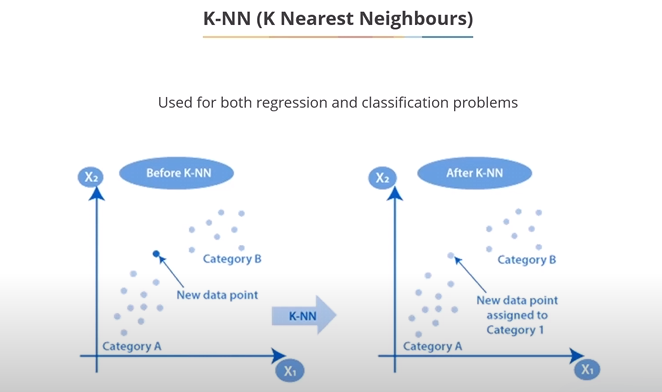

-> K-Means est souvent qualifié d'algorithme "paresseux" (lazy) car il ne construit pas explicitement un modèle à partir des données d'entraînement comme le font les algorithmes supervisés. Au lieu de cela, il mémorise simplement les centroïdes des clusters formés pendant la phase d'entraînement.  
  
-> Pendant la phase d'entraînement, K-Means ne fait que stocker les centroïdes des clusters qu'il a déterminés. Il ne crée pas de modèle complexe ou de fonction de décision comme le feraient des algorithmes supervisés. Les centroïdes sont simplement les centres de gravité des clusters formés.
  
->Lorsqu'un nouveau point de données est introduit, K-Means détermine à quel cluster il appartient en calculant la distance entre ce point et les centroïdes des clusters. Le point est assigné au cluster dont le centroïde est le plus proche.  
La distance la plus couramment utilisée est la distance euclidienne, mais d'autres mesures de distance peuvent également être utilisées.


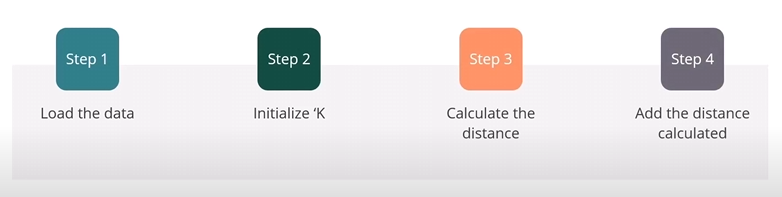

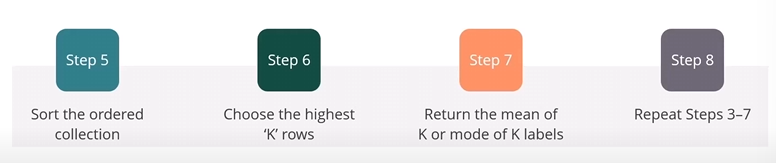

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/sakshi2k/Social_Network_Ads/refs/heads/master/Social_Network_Ads.csv')

In [6]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [10]:
df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

Les modèles de machine learning (comme la régression logistique ou les arbres de décision) ne peuvent pas travailler directement avec des données catégorielles comme "Male" et "Female". Ils ont besoin de données numériques. Donc, on doit convertir ces catégories en nombres.

In [ ]:
# Create dummy variables for the 'Gender' column, dropping the first category to avoid multicollinearity
gender = pd.get_dummies(df['Gender'], drop_first=True)#b9at ghir male f gender column

# Concatenate the dummy variable column with the original DataFrame
df = pd.concat([df, gender], axis=1)

# Drop the original 'Gender' column from the DataFrame
df.drop(['Gender'], axis=1, inplace=True)

In [12]:
df.head()

,User ID,Age,EstimatedSalary,Purchased,Male
0,15624510,19,19000,0,True
1,15810944,35,20000,0,True
2,15668575,26,43000,0,False
3,15603246,27,57000,0,False
4,15804002,19,76000,0,True


In [13]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [14]:
#StandardScaler class is used to standardize features by removing the mean and scaling to unit variance.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#This line fits the scaler to the data X
scaler.fit(X)
scaled_features = scaler.transform(X)

Beaucoup d'algorithmes de machine learning (comme K-NN) sont sensibles à l'échelle des variables. La standardisation permet de mettre toutes les variables sur la même échelle.

In [15]:
#Creating a DataFrame from Scaled Features

df_feat = pd.DataFrame(scaled_features, columns=X.columns)
df_feat.head()

,Age,EstimatedSalary
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751


In [16]:
#Splitting the Data into Training and Testing Sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(scaled_features, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
#Making Predictions on the Test Set
pred = knn.predict(X_test)

In [19]:
#Evaluating the Model
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        52
           1       0.79      0.79      0.79        28

    accuracy                           0.85        80
   macro avg       0.84      0.84      0.84        80
weighted avg       0.85      0.85      0.85        80

